# So sánh và Đánh giá các mô hình Anomaly Detection

Notebook này thực hiện benchmarking các kiến trúc mô hình khác nhau cho bài toán dự báo và phát hiện bất thường trên tập dữ liệu vòng bi B02. Các mô hình bao gồm:
- **LSTM** (Vanilla)
- **ModernTCN** (ICLR 2024)
- **Transformer** (Small)
- **Patch-based models** (PatchLSTM, PatchTransformer)
- **Mamba-Hybrid** (CNN + Mamba)

In [1]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.7/121.7 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.1-cp312-cp312-linux_x86_64.whl size=533592144 sha256=d66a3c4c94a693e02d341cace7a6af0b72177b6afa655a25e3a6505130a68cbf
  Stored in directory: /root/.cache/pip/wheels/28/83/54/d45107838fec575b93f5d723f56351cee19a1b13bcd4ec9f3f
Successfully built mamba-ssm


In [2]:
import os
import gc
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import time
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
# Đảm bảo import được từ thư mục src
kaggle_src_path = '/kaggle/input/datasets/sunbv21/mamba-sft-source' 
if kaggle_src_path not in sys.path:
    sys.path.append(kaggle_src_path)

from src.data import B02Dataset
from src.models.baselines.lstm import LSTMForecaster
from src.models.baselines.tcn import TCNForecaster
from src.models.baselines.modern_tcn import ModernTCNForecaster
from src.models.baselines.transformer_small import TransformerForecaster
from src.models.mamba import HybridMambaCNN
from src.models.mamba.cnn_patching import CNNPatchEmbedding
from src.models.mamba.fusion_head import FusionForecastHead
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import calculate_threshold_3sigma, calculate_metrics
from sklearn.metrics import precision_recall_curve, auc as auc_score_func
from sklearn.metrics import precision_score, recall_score, f1_score # Thêm import này

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Định nghĩa các mô hình bổ trợ

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Đã sửa 'pe.size(2)' thành 'self.pe.size(2)' ở cả 2 vị trí
        return x + self.pe[:, :x.size(1), :self.pe.size(2)] if x.size(2) <= self.pe.size(2) else x + self.pe[:, :x.size(1), :]

class PatchTransformer(nn.Module):
    def __init__(self, in_channels=2, patch_size=64, stride=64, d_model=64, nhead=4, num_layers=3, horizon=512):
        super().__init__()
        self.patching = CNNPatchEmbedding(in_channels, patch_size, stride, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = FusionForecastHead(d_model, horizon, out_channels=in_channels)

    def forward(self, x):
        x = self.patching(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return self.head(x)

class PatchLSTM(nn.Module):
    def __init__(self, in_channels=2, patch_size=64, stride=64, d_model=96, num_layers=2, horizon=512):
        super().__init__()
        self.patching = CNNPatchEmbedding(in_channels, patch_size, stride, d_model)
        self.lstm = nn.LSTM(d_model, d_model, num_layers, batch_first=True)
        self.head = FusionForecastHead(d_model, horizon, out_channels=in_channels)

    def forward(self, x):
        x = self.patching(x)
        x, _ = self.lstm(x)
        return self.head(x)

## 2. Khởi tạo Dataset

In [4]:
# processed_dir = '../../data/processed'
# full_dataset = B02Dataset(processed_dir, lookback=1024, horizon=512, stride=512, split='train')

# train_subset = Subset(full_dataset, range(0, 5000))
# test_subset = Subset(full_dataset, range(0, 10000))
# test_subset_last = Subset(full_dataset, range(len(full_dataset) - 500, len(full_dataset)))

# batch_size = 128
# train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
# last_loader = DataLoader(test_subset_last, batch_size=batch_size, shuffle=False)

# print(f"Total dataset size: {len(full_dataset)}")
# print(f"Train size: {len(train_subset)}")
# print(f"Test size: {len(test_subset)}")

processed_dir = '/kaggle/input/datasets/sunbv21/dataset-bearings'
lookback, horizon, stride = 1024, 512, 512

# Load 3 tập riêng biệt dựa trên logic 80/10/10 của Dataset.py
train_dataset = B02Dataset(processed_dir, lookback, horizon, stride, split='train')
val_dataset = B02Dataset(processed_dir, lookback, horizon, stride, split='val')
test_dataset = B02Dataset(processed_dir, lookback, horizon, stride, split='test')

# # (option) Giảm dữ liệu
train_dataset = Subset(train_dataset, range(0, len(train_dataset), 35))
val_dataset = Subset(val_dataset, range(0, len(val_dataset), 10))
test_dataset = Subset(test_dataset, range(0, len(test_dataset), 10))
# train_dataset = Subset(train_dataset, range(len(train_dataset) - 1, -1, -35))
# val_dataset = Subset(val_dataset, range(len(val_dataset) - 1, -1, -10))
# test_dataset = Subset(test_dataset, range(len(test_dataset) - 1, -1, -10))

# Sử dụng toàn bộ dữ liệu của từng split thay vì Subset nhỏ
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"--- Thông số Dataset (80/10/10) ---")
print(f"Total Train samples: {len(train_dataset)} (Files 0 - 891: Chứa 800 file Healthy + 92 file bắt đầu lỗi)")
print(f"Total Val samples: {len(val_dataset)} (Files 892 - 1003: Chứa dữ liệu lỗi đang tăng dần)")
print(f"Total Test samples: {len(test_dataset)} (Files 1004 - 1115: Dữ liệu lỗi nặng/Sắp hỏng)")

--- Thông số Dataset (80/10/10) ---
Total Train samples: 10144 (Files 0 - 891: Chứa 800 file Healthy + 92 file bắt đầu lỗi)
Total Val samples: 4458 (Files 892 - 1003: Chứa dữ liệu lỗi đang tăng dần)
Total Test samples: 4458 (Files 1004 - 1115: Dữ liệu lỗi nặng/Sắp hỏng)


## 3. Khởi tạo mô hình (Mục tiêu 200k-250k Params)

In [5]:
models = {
    "LSTM": LSTMForecaster(input_dim=2, hidden_dim=80, num_layers=3, horizon=512),
    "PatchLSTM": PatchLSTM(in_channels=2, patch_size=64, stride=64, d_model=80, num_layers=3, horizon=512),
    "ModernTCN": ModernTCNForecaster(input_dim=2, d_model=96, num_layers=3, kernel_size=17, horizon=512),
    "Transformer": TransformerForecaster(input_dim=2, d_model=64, nhead=4, num_layers=3, horizon=512),
    "PatchTransformer": PatchTransformer(in_channels=2, patch_size=64, stride=64, d_model=64, nhead=4, num_layers=3, horizon=512),
    "Mamba-Hybrid": HybridMambaCNN({
        'model': {
            'cnn_out_channels': 64, 'mamba_d_model': 64, 'mamba_n_layer': 4,
            'mamba_d_state': 16, 'mamba_d_conv': 4, 'mamba_expand': 2,
            'forecast_len': 512, 'patch_size': 64, 'stride': 64,
            'in_channels': 2, 'out_channels': 2
        },
        'data': {'patch_size': 64, 'stride': 64}
    })
}

for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: {n_params:,} parameters")

# # Cấu hình Multi-GPU
# for name, model in models.items():
#     # 1. Đếm số lượng tham số trước khi wrap
#     n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"{name}: {n_params:,} parameters")
    
#     # 2. Chuyển vào device và wrap DataParallel nếu có nhiều GPU
#     if torch.cuda.device_count() > 1 and "Mamba" not in name:
#         print(f"   => Sử dụng {torch.cuda.device_count()} GPUs cho {name}")
#         models[name] = nn.DataParallel(model)
#     elif "Mamba" in name:
#         print(f"   => Chạy {name} trên 1 GPU để tránh lỗi Deadlock của Mamba-SSM.")

LSTM: 213,664 parameters
PatchLSTM: 246,464 parameters
ModernTCN: 217,792 parameters
Transformer: 216,704 parameters
PatchTransformer: 222,912 parameters
Mamba-Hybrid: 208,320 parameters


## 4. Huấn luyện và Đánh giá

In [6]:
results = {}
criterion = nn.MSELoss()
epochs = 100
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

for name, model in models.items():
    print(f"\n>>> Đang huấn luyện {name}...")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    losses = []
    
    # 1. Training Loop
    start_train = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            if len(batch) == 3: x, y, _ = batch
            else: x, y = batch
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                y_pred = model(x)
                loss = criterion(y_pred, y)
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_loader))

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch [{epoch}/{epochs}] - Loss: {total_loss / len(train_loader):.6f}")
            
    train_duration = time.time() - start_train

    # --- FIX QUAN TRỌNG 1: TÍNH THRESHOLD TỪ TẬP TRAIN ---
    # Vì Train chứa >90% là trạng thái Healthy, ta dùng nó làm chuẩn để tính ngưỡng
    train_scores_sample = []
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(train_loader):
            if i > 20: break # Chỉ cần khoảng 20 batch (~1200 mẫu) để ước tính phân phối Healthy
            x, y = batch[0].to(device), batch[1].to(device)
            y_pred = model(x)
            scores = calculate_anomaly_score(y, y_pred, metric='mse')
            train_scores_sample.extend(scores.tolist())
            
    # Chốt Threshold dựa trên đặc trưng của vòng bi lúc khỏe mạnh
    threshold = calculate_threshold_3sigma(np.array(train_scores_sample))

    # 2. Evaluation on Validation Set
    val_scores = []
    latencies = []
    
    with torch.no_grad():
        for batch in test_loader:
            # --- FIX 1: LOẠI BỎ HOÀN TOÀN NHÃN GIẢ ---
            # Chỉ lấy x (input) và y (target forecasting), bỏ qua phần tử thứ 3 nếu có
            x, y = batch[0].to(device), batch[1].to(device)
            
            start_inf = time.time()
            y_pred = model(x)
            latencies.append((time.time() - start_inf) / x.size(0))
            
            scores = calculate_anomaly_score(y, y_pred, metric='mse')
            val_scores.extend(scores.tolist())
    
    val_scores = np.array(val_scores)
    
    # --- FIX 2: TẠO TẬP ĐÁNH GIÁ CHUẨN KẾT HỢP (HEALTHY + FAULTY) ---
    # Kết hợp điểm của tập Train (giả định 100% Healthy -> nhãn 0)
    # và điểm của tập Val (giả định đang lỗi dần -> nhãn 1)
    combined_scores = np.concatenate([train_scores_sample, val_scores])
    
    combined_labels = np.concatenate([
        np.zeros(len(train_scores_sample)), 
        np.ones(len(val_scores))
    ]).astype(int) # Ép kiểu về số nguyên chuẩn 1D Binary
    
    # Tính nhãn dự đoán dựa trên ngưỡng (Threshold) đã chốt từ tập Train
    pred_labels = (combined_scores > threshold).astype(int)
    
    # Tính toán AUC và AUPRC trên tập kết hợp
    try:
        metrics = calculate_metrics(combined_scores, combined_labels, threshold)
        precision_path, recall_path, _ = precision_recall_curve(combined_labels, combined_scores)
        auprc = auc_score_func(recall_path, precision_path)
    except Exception as e:
        metrics = {'AUC': 0.0}
        auprc = 0.0

    # Tính Precision, Recall và F1
    calc_precision = precision_score(combined_labels, pred_labels, zero_division=0)
    calc_recall = recall_score(combined_labels, pred_labels, zero_division=0)
    calc_f1 = f1_score(combined_labels, pred_labels, zero_division=0)

    # 3. Last 500 Samples Evaluation (Tập test cuối cùng)
    last_scores = []
    with torch.no_grad():
        for batch in test_loader:
            if len(batch) == 3: x, y, _ = batch
            else: x, y = batch
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            scores = calculate_anomaly_score(y, y_pred, metric='mse')
            last_scores.extend(scores.tolist())
    
    last_scores = np.array(last_scores)
    detection_rate = np.sum(last_scores > threshold) / len(last_scores)

    # Lưu kết quả
    results[name] = {
        'losses': losses,
        'f1': calc_f1,
        'auc': metrics.get('AUC', 0),
        'precision': calc_precision,
        'recall': calc_recall,
        'auprc': auprc,
        'latency': np.mean(latencies) * 1000,
        'detection_rate': detection_rate,
        'last_scores': last_scores[-500:], # Chỉ lưu 500 mẫu cuối để vẽ biểu đồ cho nhẹ
        'threshold': float(threshold)
    }
    
    print(f"✅ {name} Xong!")
    print(f"   > F1: {calc_f1:.4f} | AUC: {metrics.get('AUC', 0):.4f} | AUPRC: {auprc:.4f}")
    print(f"   > Precision: {calc_precision:.4f} | Recall: {calc_recall:.4f}")
    print(f"   > Latency: {results[name]['latency']:.4f} ms/sample | Det.Rate (test dataset): {detection_rate:.2%}")

    # --- THÊM ĐOẠN NÀY VÀO CUỐI VÒNG LẶP ---
    # Giải phóng hoàn toàn model khỏi bộ nhớ
    del model
    optimizer.zero_grad(set_to_none=True)
    
    # Dọn dẹp RAM hệ thống và VRAM GPU
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


>>> Đang huấn luyện LSTM...
Epoch [1/100] - Loss: 1.008051
Epoch [10/100] - Loss: 0.815097
Epoch [20/100] - Loss: 0.789126
Epoch [30/100] - Loss: 0.777954
Epoch [40/100] - Loss: 0.762639
Epoch [50/100] - Loss: 0.751045
Epoch [60/100] - Loss: 0.739060
Epoch [70/100] - Loss: 0.726490
Epoch [80/100] - Loss: 0.711457
Epoch [90/100] - Loss: 0.701439
Epoch [100/100] - Loss: 0.687971
✅ LSTM Xong!
   > F1: 0.2257 | AUC: 0.6340 | AUPRC: 0.7811
   > Precision: 0.9485 | Recall: 0.1281
   > Latency: 0.0072 ms/sample | Det.Rate (test dataset): 12.81%

>>> Đang huấn luyện PatchLSTM...
Epoch [1/100] - Loss: 1.073766
Epoch [10/100] - Loss: 0.863288
Epoch [20/100] - Loss: 0.780940
Epoch [30/100] - Loss: 0.725152
Epoch [40/100] - Loss: 0.686993
Epoch [50/100] - Loss: 0.655647
Epoch [60/100] - Loss: 0.626759
Epoch [70/100] - Loss: 0.603018
Epoch [80/100] - Loss: 0.580517
Epoch [90/100] - Loss: 0.558104
Epoch [100/100] - Loss: 0.535640
✅ PatchLSTM Xong!
   > F1: 0.5453 | AUC: 0.8217 | AUPRC: 0.9032
   > 

## 5. Trực quan hóa kết quả

/tmp/ipykernel_23/2273565515.py:50: UserWarning: Glyph 7881 (\N{LATIN SMALL LETTER I WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2273565515.py:50: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2273565515.py:50: UserWarning: Glyph 7845 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2273565515.py:50: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2273565515.py:50: UserWarning: Glyph 7907 (\N{LATIN SMALL LETTER O WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2273565515.py:50: UserWarning: Glyph 7857 (\N{LATIN SMALL LETTER A WITH BREVE AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/t

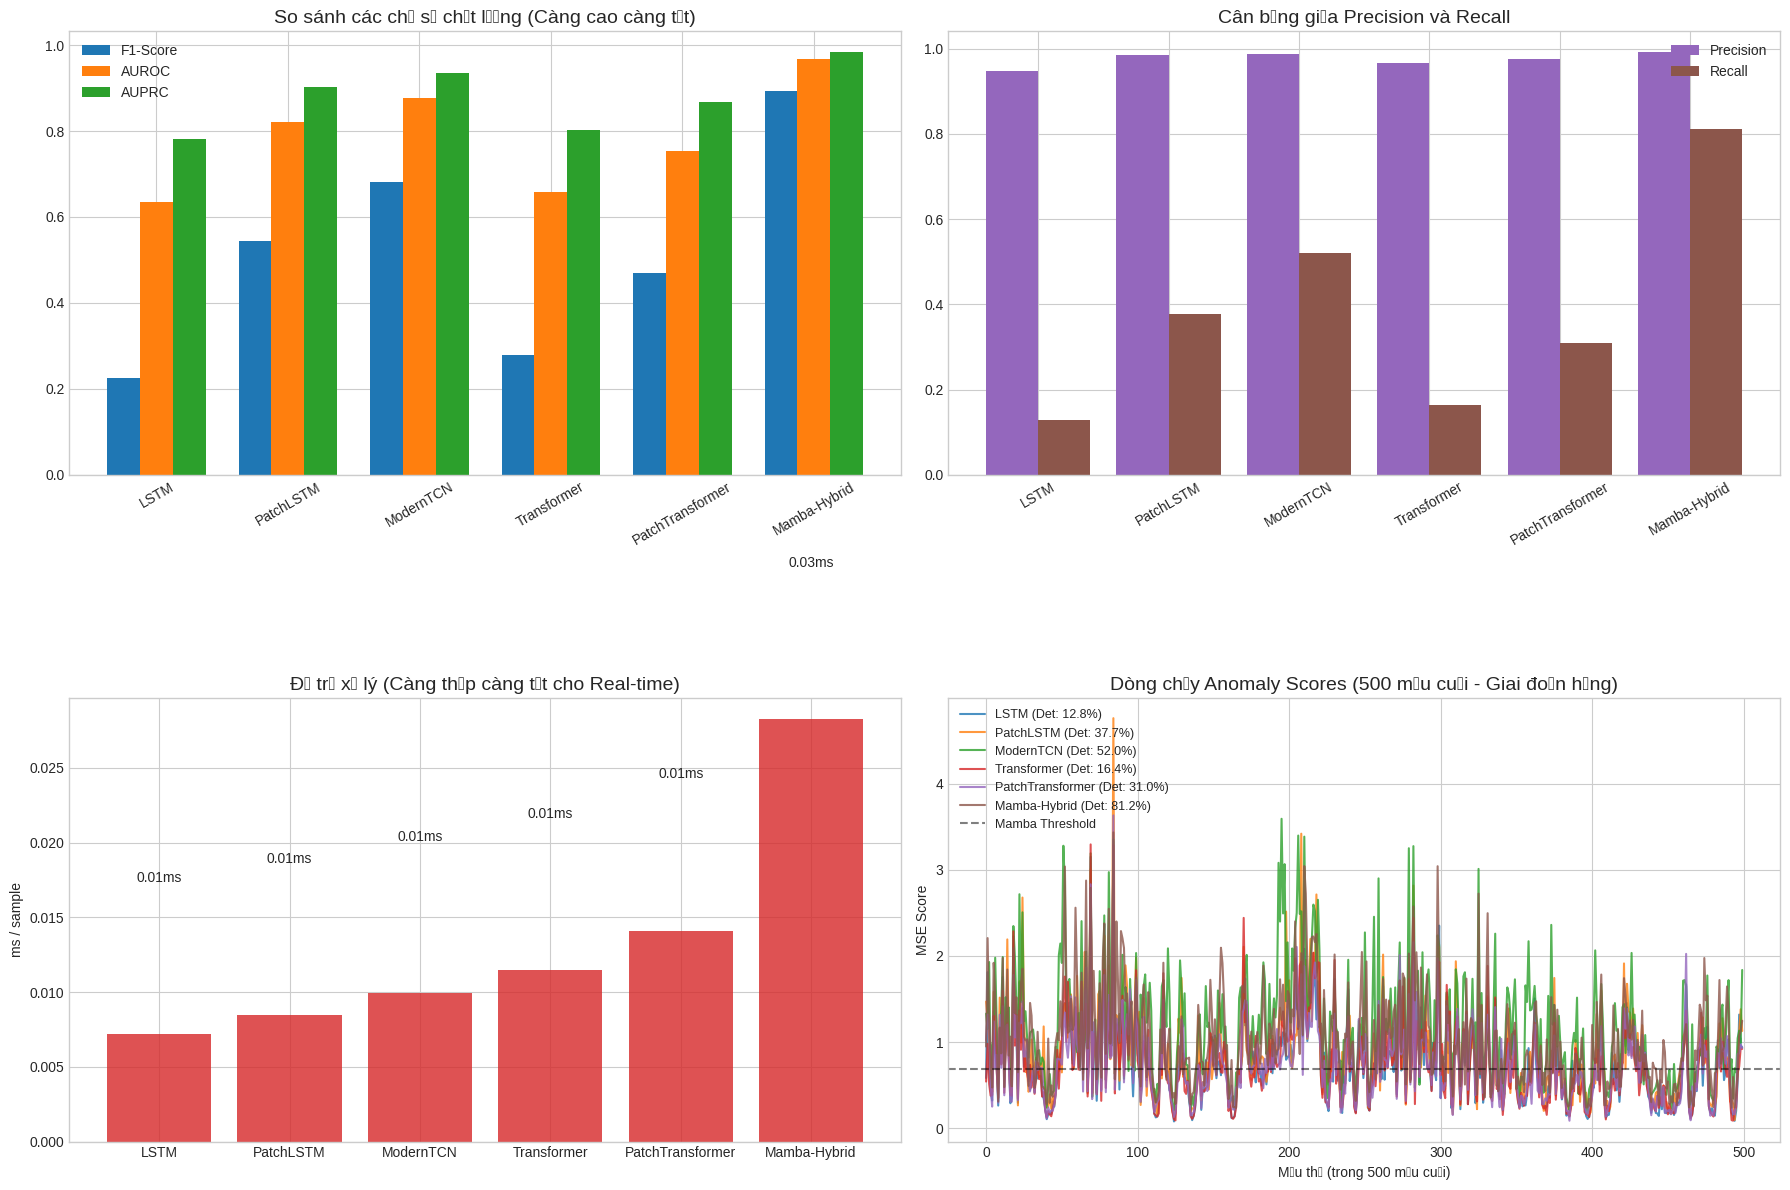

In [7]:
plt.style.use('seaborn-v0_8-whitegrid') # Sử dụng style sạch sẽ
fig = plt.figure(figsize=(18, 12))

names = list(results.keys())
x = np.arange(len(names))

# --- 5.1 So sánh F1, AUC và AUPRC ---
ax1 = plt.subplot(2, 2, 1)
width = 0.25
ax1.bar(x - width, [results[n]['f1'] for n in names], width, label='F1-Score', color='#1f77b4')
ax1.bar(x, [results[n]['auc'] for n in names], width, label='AUROC', color='#ff7f0e')
ax1.bar(x + width, [results[n]['auprc'] for n in names], width, label='AUPRC', color='#2ca02c')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=30)
ax1.set_title("So sánh các chỉ số chất lượng (Càng cao càng tốt)", fontsize=14)
ax1.legend()

# --- 5.2 So sánh Precision và Recall ---
ax2 = plt.subplot(2, 2, 2)
ax2.bar(x - 0.2, [results[n]['precision'] for n in names], 0.4, label='Precision', color='#9467bd')
ax2.bar(x + 0.2, [results[n]['recall'] for n in names], 0.4, label='Recall', color='#8c564b')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=30)
ax2.set_title("Cân bằng giữa Precision và Recall", fontsize=14)
ax2.legend()

# --- 5.3 So sánh Độ trễ (Latency) ---
ax3 = plt.subplot(2, 2, 3)
latencies = [results[n]['latency'] for n in names]
bars = ax3.bar(names, latencies, color='#d62728', alpha=0.8)
ax3.set_ylabel("ms / sample")
ax3.set_title("Độ trễ xử lý (Càng thấp càng tốt cho Real-time)", fontsize=14)
# Thêm giá trị trên đầu cột
for bar in bars:
    yval = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}ms', ha='center', va='bottom')

# --- 5.4 Biểu đồ Anomaly Scores (500 mẫu cuối) ---
ax4 = plt.subplot(2, 2, 4)
for name in names:
    ax4.plot(results[name]['last_scores'], label=f"{name} (Det: {results[name]['detection_rate']:.1%})", alpha=0.8)

# Vẽ ngưỡng của Mamba-Hybrid làm chuẩn
ax4.axhline(y=results['Mamba-Hybrid']['threshold'], color='black', linestyle='--', alpha=0.5, label='Mamba Threshold')
ax4.set_title("Dòng chảy Anomaly Scores (500 mẫu cuối - Giai đoạn hỏng)", fontsize=14)
ax4.set_xlabel("Mẫu thứ (trong 500 mẫu cuối)")
ax4.set_ylabel("MSE Score")
ax4.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_23/3517076946.py:52: UserWarning: Glyph 7851 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND TILDE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3517076946.py:52: UserWarning: Glyph 7913 (\N{LATIN SMALL LETTER U WITH HORN AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3517076946.py:52: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3517076946.py:52: UserWarning: Glyph 7853 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3517076946.py:52: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3517076946.py:52: UserWarning: Glyph 7901 (\N{LATIN SMALL LETTER O WITH HORN AND GRAVE}) missing from font(s) Liberation

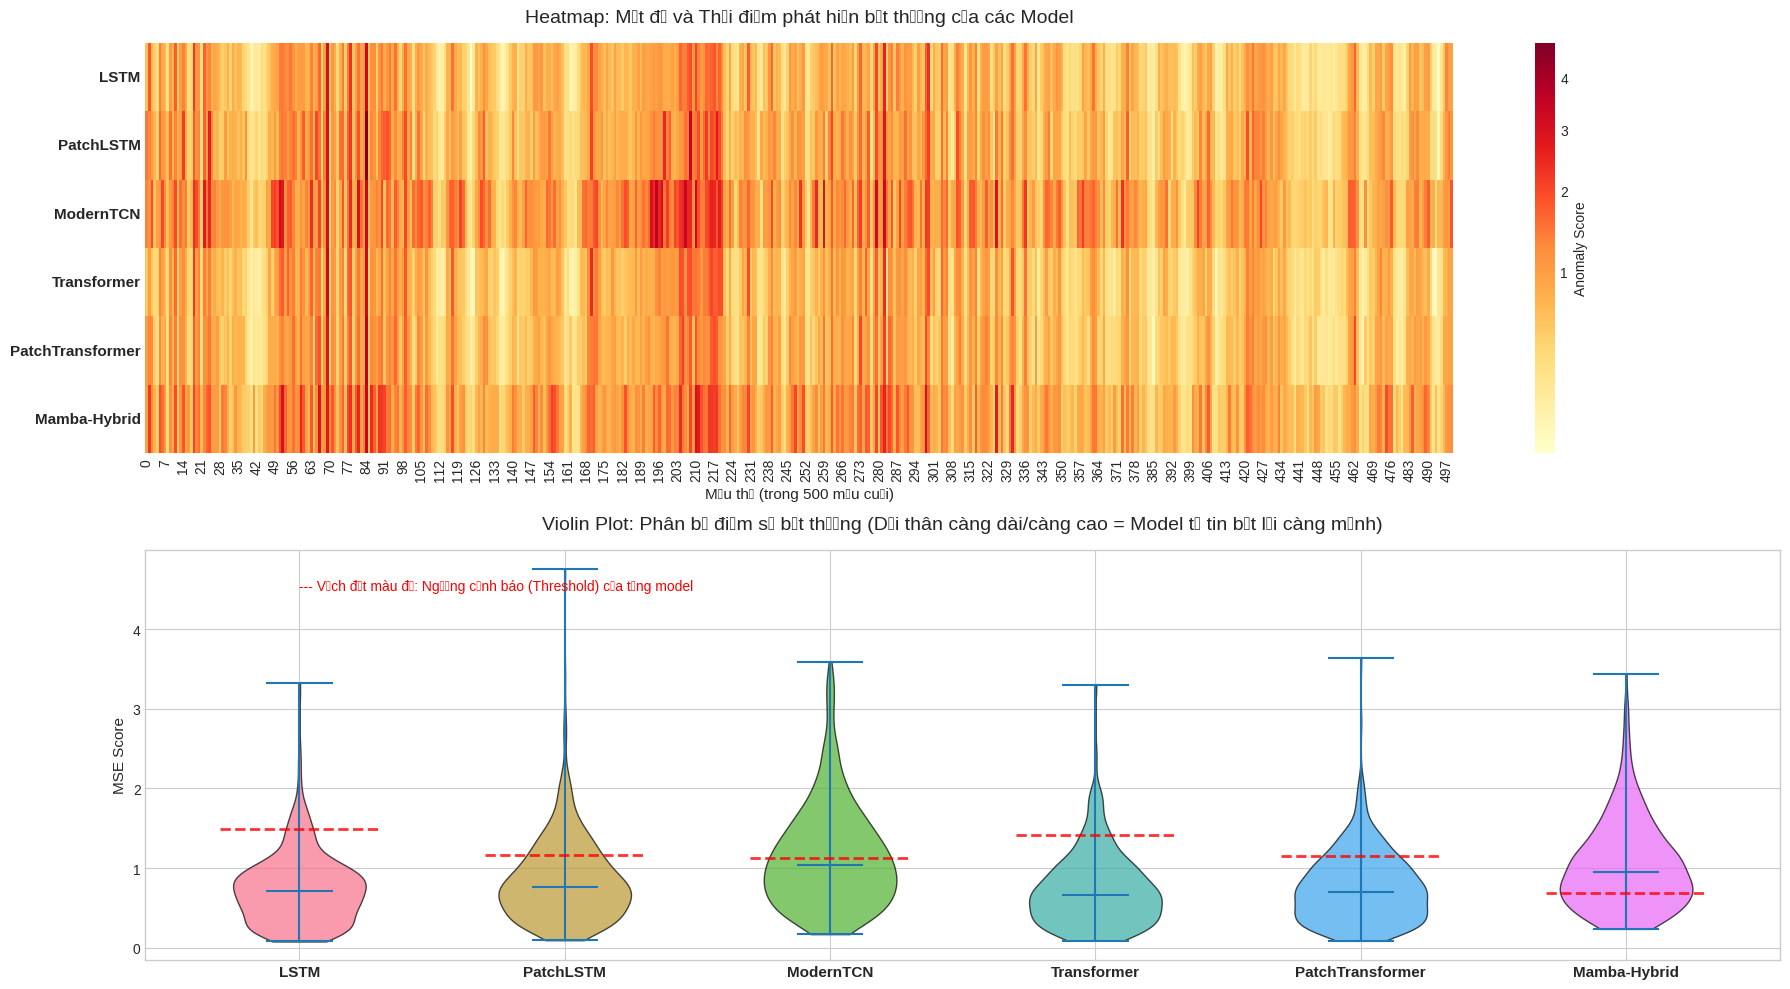

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
names = list(results.keys())
scores_matrix = np.array([results[name]['last_scores'] for name in names])

fig = plt.figure(figsize=(18, 10))

# ==========================================
# 1. HEATMAP: Trực quan hóa theo thời gian
# ==========================================
ax1 = plt.subplot(2, 1, 1)
# Chuẩn hóa dữ liệu một chút để heatmap hiện màu đẹp hơn (tránh bị nhiễu bởi 1 điểm quá lớn)
import matplotlib.colors as mcolors
norm = mcolors.PowerNorm(gamma=0.5) # Giúp màu sắc hiển thị rõ hơn với các điểm bất thường

sns.heatmap(scores_matrix, cmap="YlOrRd", ax=ax1, norm=norm, cbar_kws={'label': 'Anomaly Score'})
ax1.set_yticks(np.arange(len(names)) + 0.5)
ax1.set_yticklabels(names, rotation=0, fontsize=11, fontweight='bold')
ax1.set_xlabel("Mẫu thứ (trong 500 mẫu cuối)", fontsize=11)
ax1.set_title("Heatmap: Mật độ và Thời điểm phát hiện bất thường của các Model", fontsize=14, pad=15)

# ==========================================
# 2. VIOLIN PLOT: So sánh sự phân bố điểm số
# ==========================================
ax2 = plt.subplot(2, 1, 2)
data_to_plot = [results[name]['last_scores'] for name in names]

# Vẽ Violin plot để xem hình dáng phân phối
parts = ax2.violinplot(data_to_plot, showmeans=False, showmedians=True, showextrema=True)

# Trang trí Violin plot
colors = sns.color_palette("husl", len(names))
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

ax2.set_xticks(np.arange(1, len(names) + 1))
ax2.set_xticklabels(names, fontsize=11, fontweight='bold')
ax2.set_ylabel("MSE Score", fontsize=11)
ax2.set_title("Violin Plot: Phân bố điểm số bất thường (Dải thân càng dài/càng cao = Model tự tin bắt lỗi càng mạnh)", fontsize=14, pad=15)

# Vẽ thêm vạch Threshold cho từng model (tùy chọn)
for i, name in enumerate(names):
    ax2.hlines(results[name]['threshold'], i+0.7, i+1.3, color='red', linestyle='--', alpha=0.8, linewidth=2)
    
ax2.text(1, ax2.get_ylim()[1]*0.9, "--- Vạch đứt màu đỏ: Ngưỡng cảnh báo (Threshold) của từng model", color='red', fontsize=10)

plt.tight_layout()
plt.show()